In [22]:
# imports
import os
import numpy as np
import pandas as pd
import glob
import tqdm
import matplotlib.pyplot as plt

#
from typing import List, Text, Dict, Union, Tuple
from sklearn.preprocessing import LabelEncoder, StandardScaler

#
from xgboost import XGBClassifier
from sklearn.metrics import log_loss
from sklearn.model_selection import KFold
import datetime as dt


In [23]:
# print all the filenames in the data directory
for dirname, _, filenames in os.walk('data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

data/pump-fun-graduation-february-2025/chunk_11.csv
data/pump-fun-graduation-february-2025/chunk_14.csv
data/pump-fun-graduation-february-2025/chunk_15.csv
data/pump-fun-graduation-february-2025/chunk_10.csv
data/pump-fun-graduation-february-2025/chunk_3.csv
data/pump-fun-graduation-february-2025/chunk_21.csv
data/pump-fun-graduation-february-2025/chunk_24.csv
data/pump-fun-graduation-february-2025/chunk_40.csv
data/pump-fun-graduation-february-2025/chunk_16.csv
data/pump-fun-graduation-february-2025/chunk_4.csv
data/pump-fun-graduation-february-2025/dune_token_info_v2.csv
data/pump-fun-graduation-february-2025/chunk_41.csv
data/pump-fun-graduation-february-2025/chunk_8.csv
data/pump-fun-graduation-february-2025/chunk_32.csv
data/pump-fun-graduation-february-2025/chunk_22.csv
data/pump-fun-graduation-february-2025/chunk_18.csv
data/pump-fun-graduation-february-2025/chunk_20.csv
data/pump-fun-graduation-february-2025/test_unlabeled.csv
data/pump-fun-graduation-february-2025/dune_token_i

In [24]:
path = 'data/'

In [25]:
# === 1. Load main train/test data ===
df_train = pd.read_csv(path+"pump-fun-graduation-february-2025/train.csv")
df_test = pd.read_csv(path+"pump-fun-graduation-february-2025/test_unlabeled.csv")

# === 2. Load additional data ===
# Loading extra data.
df_info1 = pd.read_csv(path+"pump-fun-graduation-february-2025/dune_token_info.csv")
df_info2 = pd.read_csv(path+"pump-fun-graduation-february-2025/dune_token_info_v2.csv")
df_token_info1 = pd.read_csv(path+"pump-fun-graduation-february-2025/token_info_onchain_divers.csv")
df_token_info2 = pd.read_csv(path+"pump-fun-graduation-february-2025/token_info_onchain_divers_v2.csv")

/tmp/ipykernel_3087158/1352849146.py:9: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_token_info1 = pd.read_csv(path+"pump-fun-graduation-february-2025/token_info_onchain_divers.csv")


In [26]:
print(" === Train data === ")
df_train.info()
print(" === Test data === ")
df_test.info()

 === Train data === 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639557 entries, 0 to 639556
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      639557 non-null  int64  
 1   mint            639557 non-null  object 
 2   slot_min        639557 non-null  int64  
 3   slot_graduated  7404 non-null    float64
 4   has_graduated   639557 non-null  bool   
 5   is_valid        639557 non-null  bool   
dtypes: bool(2), float64(1), int64(2), object(1)
memory usage: 20.7+ MB
 === Test data === 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478832 entries, 0 to 478831
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  478832 non-null  int64 
 1   mint        478832 non-null  object
 2   slot_min    478832 non-null  int64 
 3   is_valid    478832 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 11

In [27]:
categorical_column_names = ["mint"] # can be used as index.
numerical_column_names = ["slot_min"]
column_name_to_predict = "has_graduated"

## Merging Data

In [28]:
df_info = pd.concat([df_info1, df_info2])
df_info = df_info.drop(columns=["name", "token_uri"])
df_info = df_info.drop_duplicates()
df_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2035188 entries, 0 to 2035187
Data columns (total 5 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   token_mint_address  object
 1   decimals            int64 
 2   symbol              object
 3   created_at          object
 4   init_tx             object
dtypes: int64(1), object(4)
memory usage: 93.2+ MB


In [29]:
# Merging with train data.
df_train_with_extra = df_train.merge(
    df_info,
    left_on="mint",
    right_on="token_mint_address",
    how="left",
)
df_train_with_extra = df_train_with_extra.drop(columns=["token_mint_address"])
assert len(df_train) == len(df_train_with_extra)
df_train_with_extra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639557 entries, 0 to 639556
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      639557 non-null  int64  
 1   mint            639557 non-null  object 
 2   slot_min        639557 non-null  int64  
 3   slot_graduated  7404 non-null    float64
 4   has_graduated   639557 non-null  bool   
 5   is_valid        639557 non-null  bool   
 6   decimals        639557 non-null  int64  
 7   symbol          639155 non-null  object 
 8   created_at      639557 non-null  object 
 9   init_tx         639557 non-null  object 
dtypes: bool(2), float64(1), int64(3), object(4)
memory usage: 40.3+ MB


In [30]:
# Merging with test data.
df_test_with_extra = df_test.merge(
    df_info,
    left_on="mint",
    right_on="token_mint_address",
    how="left",
)
df_test_with_extra = df_test_with_extra.drop(columns=["token_mint_address"])
assert len(df_test) == len(df_test_with_extra)
df_test_with_extra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478832 entries, 0 to 478831
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  478832 non-null  int64  
 1   mint        478832 non-null  object 
 2   slot_min    478832 non-null  int64  
 3   is_valid    478832 non-null  bool   
 4   decimals    429343 non-null  float64
 5   symbol      429054 non-null  object 
 6   created_at  429343 non-null  object 
 7   init_tx     429343 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(4)
memory usage: 26.0+ MB


In [31]:
# Merging with token info data.
df_token_info = pd.concat([df_token_info1, df_token_info2])
df_token_info = df_token_info.drop(columns=["name", "creator", "url", "bundle_structure", "curve_address", "version"])
df_token_info = df_token_info.drop_duplicates()
df_token_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1772581 entries, 0 to 1168711
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   block_time               object 
 1   slot                     object 
 2   tx_idx                   object 
 3   symbol                   object 
 4   mint                     object 
 5   bundle_size              float64
 6   gas_used                 float64
 7   bundled_buys             float64
 8   bundled_buys_count       float64
 9   dev_balance              float64
 10  creation_ix_index        float64
 11  direct_pf_invocation     float64
 12  amount_of_instructions   float64
 13  amount_of_lookup_reads   float64
 14  amount_of_lookup_writes  float64
 15  pf_program_index         float64
dtypes: float64(11), object(5)
memory usage: 229.9+ MB


In [32]:
# Merging extra columns to the train extra set.
# N.B.: mints are not unique here. Left joining ends up with having more rows.
#       Training with this extra data does not improve the model. -> log_loss reachs 3.7%.
#       Simple filter with iloc fixes the 'problem'.
#       More data-analysis should be maid here to understand why, and what meaning we can push to the model with the extra lines.
#       Next step.
df_train_with_extra_token = df_train_with_extra.merge(
    df_token_info,
    on="mint",
    how="left",
)
df_train_with_extra_token["symbol"] = df_train_with_extra_token['symbol_x'].combine_first(df_train_with_extra_token["symbol_y"])
df_train_with_extra_token = df_train_with_extra_token.drop(columns=[
    "Unnamed: 0", "symbol_x", "symbol_y",
])
df_train_with_extra_token = df_train_with_extra_token.drop_duplicates()
df_train_with_extra_token = df_train_with_extra_token.iloc[:len(df_train)] # Not clean
# Coming back to starting length.
assert len(df_train) == len(df_train_with_extra_token), f"{len(df_train):_} vs {len(df_train_with_extra_token):_}"
df_train_with_extra_token.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639557 entries, 0 to 639556
Data columns (total 23 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   mint                     639557 non-null  object 
 1   slot_min                 639557 non-null  int64  
 2   slot_graduated           6890 non-null    float64
 3   has_graduated            639557 non-null  bool   
 4   is_valid                 639557 non-null  bool   
 5   decimals                 639557 non-null  int64  
 6   created_at               639557 non-null  object 
 7   init_tx                  639557 non-null  object 
 8   block_time               639193 non-null  object 
 9   slot                     639193 non-null  object 
 10  tx_idx                   639193 non-null  object 
 11  bundle_size              639193 non-null  float64
 12  gas_used                 639193 non-null  float64
 13  bundled_buys             639193 non-null  float64
 14  bund

In [33]:
df_test_with_extra_token = df_test_with_extra.merge(
    df_token_info,
    on="mint",
    how="left",
)
df_test_with_extra_token["symbol"] = df_test_with_extra_token['symbol_x'].combine_first(df_test_with_extra_token["symbol_y"])
df_test_with_extra_token = df_test_with_extra_token.drop(columns=[
    "symbol_x", "symbol_y",
])
df_test_with_extra_token = df_test_with_extra_token.drop_duplicates()
df_test_with_extra_token = df_test_with_extra_token.iloc[:len(df_test)] # Not clean
# Coming back to starting length.
assert len(df_test) == len(df_test_with_extra_token), f"{len(df_test):_} vs {len(df_test_with_extra_token):_}"
df_test_with_extra_token.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478832 entries, 0 to 478831
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               478832 non-null  int64  
 1   mint                     478832 non-null  object 
 2   slot_min                 478832 non-null  int64  
 3   is_valid                 478832 non-null  bool   
 4   decimals                 429353 non-null  float64
 5   created_at               429353 non-null  object 
 6   init_tx                  429353 non-null  object 
 7   block_time               450729 non-null  object 
 8   slot                     450729 non-null  object 
 9   tx_idx                   450729 non-null  object 
 10  bundle_size              450729 non-null  float64
 11  gas_used                 450729 non-null  float64
 12  bundled_buys             450729 non-null  float64
 13  bundled_buys_count       450729 non-null  float64
 14  dev_

# Filling NA values

In [37]:
def fillna(df: pd.DataFrame) -> pd.DataFrame:
    """Filling na values.

    :param df: Entry DataFrame.
    :return pd.DataFrame: output DataFrame with filled columns.
    :notes:
    - This is a simple version, doing it with more accuracy after EDA must improve the logloss.
    """
    # Copying.
    df_filled = df.copy()
    # Iterating over columns.
    for column_name in df_filled.columns:
        if column_name in [column_name_to_predict]:
            continue
        elif df_filled[column_name].dtype in ["category", "object"]:
            value = df_filled[column_name].mode()[0]
        elif df_filled[column_name].dtype in ["float32", "float64"]:
            value = df_filled[column_name].mean()
        elif df_filled[column_name].dtype in ["int8", "int16", "int32", "int64"]:
            value = df_filled[column_name].mode()[0]
        elif df_filled[column_name].dtype == "bool":
            value = df_filled[column_name].mode()[0]
        else:
            raise TypeError(f"{column_name}: {df_filled[column_name].dtype}.")
        df_filled[column_name] = df_filled[column_name].fillna(value=value)
    # Returning filled df.
    return df_filled
    

def optimize(df: pd.DataFrame) -> pd.DataFrame:
    """Optimize the column types to improve the memory usage.

    :param df: Entry DataFrame.
    :return pd.DataFrame: memory optimized DataFrame.
    """
    # Copying
    new_df = df.copy()
    # Iterate over columns
    for column_name in df.columns:
        if column_name in ["mint", "init_tx"]:  # Skip unnecessary columns
            continue
        elif column_name in ["dev_balance"]:
            new_df[column_name] = new_df[column_name].astype("float64")
        elif column_name in ["tx_idx", "bundle_size"]:
            new_df[column_name] = new_df[column_name].astype("int16")
        elif column_name in ["slot", "slot_min"]:
            new_df[column_name] = new_df[column_name].astype("int32")
        elif column_name in ["slot_graduated", "gas_used", "bundled_buys"]:
            new_df[column_name] = new_df[column_name].astype("float32")
        elif column_name in ["has_graduated", "has_slot_graduated", "is_valid"]:  # Handle bool columns
            new_df[column_name] = new_df[column_name].astype("int8")
        elif column_name in ["created_at", "block_time"]:
            new_df[column_name] = pd.to_datetime(new_df[column_name])
        elif column_name in [
            "decimals", "symbol", "creator", "bundled_buys_count", "creation_ix_index",
            "direct_pf_invocation", "amount_of_instructions", "amount_of_lookup_reads", "amount_of_lookup_writes",
            "pf_program_index", "symbol"
        ]:
            new_df[column_name] = new_df[column_name].astype("category")
        else:
            raise ValueError(f"{column_name}")
    return new_df

df_train_with_extra_token_filled = fillna(df=df_train_with_extra_token)
df_test_with_extra_token_filled = fillna(df=df_test_with_extra_token)
df_train_with_extra_token_filled_opti = optimize(df=df_train_with_extra_token_filled)
df_test_with_extra_token_filled_opti = optimize(df=df_test_with_extra_token_filled)
df_train_with_extra_token_filled.info()

/tmp/ipykernel_3087158/3779243032.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_filled[column_name] = df_filled[column_name].fillna(value=value)


ValueError: Unnamed: 0

## Encoding Data Frame

In [ ]:
from typing import List, Text, Dict, Union, Tuple
from sklearn.preprocessing import LabelEncoder, StandardScaler

def scale_and_encoder_features(
        df: pd.DataFrame,
        skip_column_names: List[Text],
    ) -> pd.DataFrame:
    """Scale the features.

    :param df: Entry DataFrame.
    :param skip_column_names: column names to skip while scaling. 
    :return pd.DataFrame: ML input ready DataFrame.
    """
    # Creating a copy.
    scaled_and_encoded_df = df.copy()
    # Iterating over features.
    for column_name in scaled_and_encoded_df.columns:
        # Preparing encoder & scaler.
        if column_name in skip_column_names:
            continue
        elif scaled_and_encoded_df[column_name].dtype in [column_name_to_predict]:
            enc = LabelEncoder()
            scaled_and_encoded_df[column_name] = enc.fit_transform(scaled_and_encoded_df.loc[:, [column_name]].values.ravel())
        elif scaled_and_encoded_df[column_name].dtype in ["category", "int8", "bool"]:
            enc = LabelEncoder()
            scaled_and_encoded_df[column_name] = enc.fit_transform(scaled_and_encoded_df.loc[:, [column_name]].values.ravel())
        elif scaled_and_encoded_df[column_name].dtype in ["int32", "float32", "int16", "float64", "int64"]:
            enc = StandardScaler()
            scaled_and_encoded_df[column_name] = enc.fit_transform(scaled_and_encoded_df.loc[:, [column_name]])
        elif scaled_and_encoded_df[column_name].dtype in ["datetime64[ns, UTC]", "datetime64[ns]"]:
            scaled_and_encoded_df[column_name] = scaled_and_encoded_df[column_name].astype('int64') // 10**9
            enc = StandardScaler()
            scaled_and_encoded_df[column_name] = enc.fit_transform(scaled_and_encoded_df.loc[:, [column_name]])
        else:
            raise TypeError(f"{column_name} - {scaled_and_encoded_df[column_name].dtype}.")
    return scaled_and_encoded_df

df_train_scale = scale_and_encoder_features(df=df_train_with_extra_token_filled_opti, skip_column_names=["mint", "init_tx"])
df_test_scale = scale_and_encoder_features(df=df_test_with_extra_token_filled_opti, skip_column_names=["mint", "init_tx"])
df_train_scale.head(3)

,mint,slot_min,slot_graduated,has_graduated,is_valid,decimals,created_at,init_tx,block_time,slot,...,bundled_buys,bundled_buys_count,dev_balance,creation_ix_index,direct_pf_invocation,amount_of_instructions,amount_of_lookup_reads,amount_of_lookup_writes,pf_program_index,symbol
0,BmTDA5HqcemLkEgpyK25sDhbvk652CTXjdWEa8fLpump,-1.777546,0.000002,0,0,0,-1.783104,3HHvJsNKWg6epToaZUouqDJdkysiJGKeBkWnhg7sPyWpFY...,-1.783501,-1.776301,...,-0.763004,2,-0.233960,3,2,5,1,1,6,3506
1,BmTDA5HqcemLkEgpyK25sDhbvk652CTXjdWEa8fLpump,-1.777546,0.000002,0,0,0,-1.783104,3HHvJsNKWg6epToaZUouqDJdkysiJGKeBkWnhg7sPyWpFY...,-1.783501,-1.776301,...,-0.763004,2,-0.233960,3,2,4,0,0,5,3506
2,4FJwryCAMMePNeWw9LTBXXfXABdkKcAxkTT6h9pdpump,-1.777536,0.000002,0,0,0,-1.783098,4rSq4SK7a6zb2hNV6x89DfwZ9XFAyy4sp1g9YQfuG8A3Ep...,-1.783495,-1.776292,...,0.133684,2,0.606723,3,2,5,1,1,6,90305


# Training XGBoost

In [ ]:
# Import
from xgboost import XGBClassifier
from sklearn.metrics import log_loss
from sklearn.model_selection import KFold
import datetime as dt

# Setting KFold
FOLDS = 7
kf = KFold(n_splits=FOLDS, shuffle=True, random_state=42)

# Preparing outputs
oof = np.zeros(len(df_train_scale))
pred = np.zeros(len(df_test_scale))
feature_column_names = list(set(df_test_scale.columns).difference(set(["mint", "init_tx"])))
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'eta': 0.01, # learning_rate
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'lambda': 1, # L2 reg
    'alpha': 0, # L1 reg
    'seed': 24,
    # 'tree_method': 'hist',
    'n_estimators': 3000,
    "enable_categorical": True,
}
start_time = dt.datetime.now()

# OUTER K FOLD
for i, (train_index, test_index) in enumerate(kf.split(df_train_scale)):
    X_train = df_train_scale.loc[train_index, feature_column_names].reset_index(drop=True).copy()
    y_train = df_train_scale.loc[train_index, column_name_to_predict]

    X_valid = df_train_scale.loc[test_index, feature_column_names].reset_index(drop=True).copy()
    y_valid = df_train_scale.loc[test_index, column_name_to_predict]

    X_test = df_test_scale.loc[:, feature_column_names].reset_index(drop=True).copy()
    
    # TRAIN SVC MODEL
    model = XGBClassifier(**xgb_params)
    
    # TRAIN MODEL
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    valid_score = log_loss(y_valid, model.predict_proba(X_valid)[:, 1])
    print(f"# Fold {i+1} - score is: {100*valid_score:.2f}%. It took {(dt.datetime.now() - start_time).seconds / 60:.2f} minutes.")

    # PREDICT OOF AND TEST
    oof[test_index] += model.predict_proba(X_valid)[:, 1]
    pred += model.predict_proba(X_test)[:,1]

pred /= FOLDS

score = log_loss(df_train_scale[column_name_to_predict], oof)
print(f"Score: {100*score:.2f}% - it took {(dt.datetime.now() - start_time).seconds / 60:.2f} minutes.")
print(f"To beat 3.49% LogLoss with {FOLDS} folds.")

KeyError: "['Unnamed: 0'] not in index"

## Feature Importance

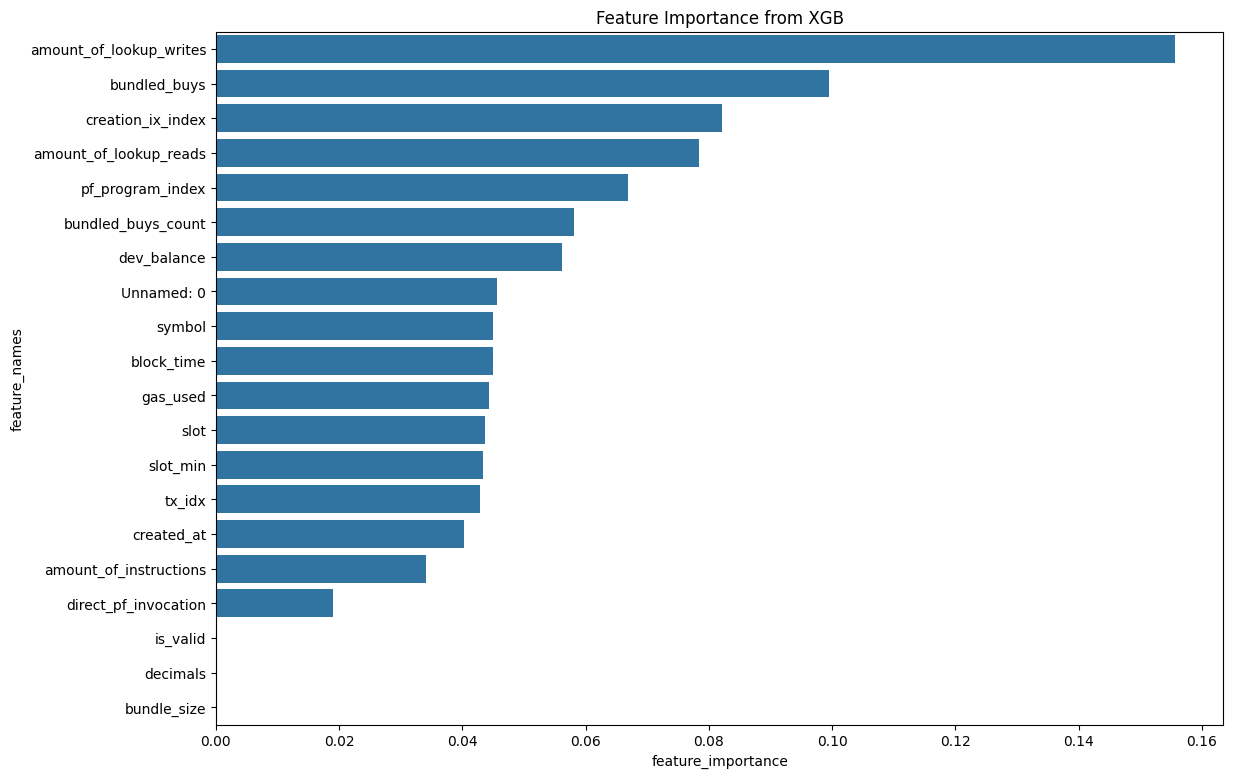

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Last model info
plt.figure(figsize=(13,9))
abs_feature_importance = abs(model.feature_importances_.reshape(-1))
sns.barplot(
    x="feature_importance",
    y="feature_names",
    data=pd.DataFrame({
        "feature_importance": abs_feature_importance,
        "feature_names": feature_column_names,
    }).sort_values(by=["feature_importance"], ascending=False),
)
plt.title("Feature Importance from XGB")
plt.show()

## Prepararing Output

In [ ]:
df_test[column_name_to_predict] = pred
df_test[["mint", column_name_to_predict]].to_csv("submission.csv", index=False, sep=",")

In [ ]:
full_merged['has_graduated'].value_counts(normalize=True).plot(kind='bar')


NameError: name 'full_merged' is not defined

In [ ]:
print(f"Unique tokens: {full_merged['mint'].nunique()}")


Unique tokens: 1118389


<Axes: >

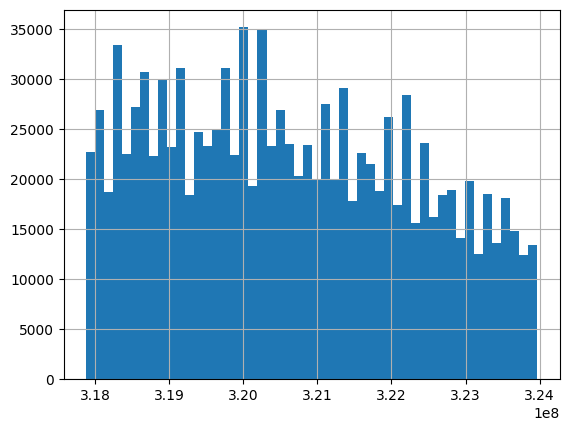

In [ ]:
full_merged['slot_min'].hist(bins=50)


In [ ]:
print(full_merged['is_valid'].value_counts())


is_valid
True     1061739
False      56652
Name: count, dtype: int64


In [ ]:
full_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118391 entries, 0 to 1118390
Data columns (total 27 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Unnamed: 0            1118391 non-null  int64  
 1   mint                  1118391 non-null  object 
 2   slot_min              1118391 non-null  int64  
 3   slot_graduated        7404 non-null     float64
 4   has_graduated         639557 non-null   object 
 5   is_valid              1118391 non-null  bool   
 6   is_test               1118391 non-null  bool   
 7   decimals              1068902 non-null  float64
 8   name_x                1068480 non-null  object 
 9   symbol_x              1068211 non-null  object 
 10  token_uri             1068863 non-null  object 
 11  created_at            1068902 non-null  object 
 12  init_tx               1068902 non-null  object 
 13  block_time            1088266 non-null  object 
 14  slot                  1088266 non-

In [ ]:
# create new dataframe with only the non null values of has_graduated
train_full = full_merged[full_merged['has_graduated'].notnull()]
test_full = full_merged[full_merged['has_graduated'].isnull()]
# check the shape of the new dataframes
print(f"Train shape: {train_full.shape}")
print(f"Test shape: {test_full.shape}")

Train shape: (639557, 27)
Test shape: (478834, 27)


In [ ]:
# convert the has_graduated column to either 0 or 1 using iloc
train_full['has_graduated'] = train_full['has_graduated'].apply(lambda x: 1 if x == True else 0)

# keep the numerical columns
num_train_full = train_full.select_dtypes(include='number').copy()
# drop unnecessary columns
num_train_full = num_train_full.drop(columns=['Unnamed: 0', 'decimals'])
num_train_full.head()

/tmp/ipykernel_2627036/1340268113.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_full['has_graduated'] = train_full['has_graduated'].apply(lambda x: 1 if x == True else 0)


,slot_min,slot_graduated,has_graduated,bundle_size,gas_used,bundled_buys,bundled_buys_count,dev_balance,creation_ix_index,direct_pf_invocation
0,317876496,NaN,0,1.0,194994.0,1.785358e+12,1.0,3.184817e+08,2.0,1.0
1,317876500,NaN,0,1.0,201798.0,6.706250e+13,1.0,5.063184e+10,2.0,1.0
2,317876500,NaN,0,1.0,187932.0,3.461290e+13,1.0,1.066126e+09,2.0,1.0
3,317876500,NaN,0,1.0,182972.0,1.262353e+14,1.0,0.000000e+00,2.0,1.0
4,317876500,NaN,0,1.0,187493.0,1.759016e+13,1.0,1.358261e+09,0.0,1.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

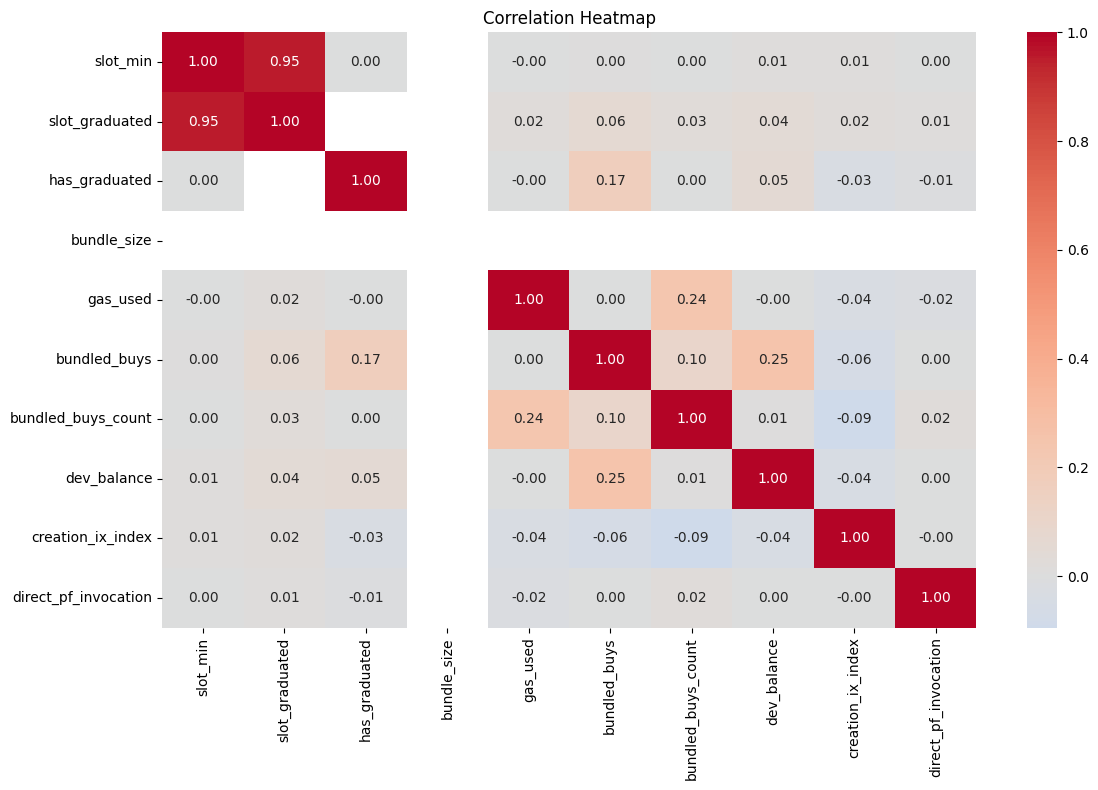

In [ ]:
# Compute and plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(num_train_full.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [ ]:
# Define features and target
features = ['gas_used', 'dev_balance', 'bundle_size', 'bundled_buys', 'bundled_buys_count']
target = 'has_graduated'

X = num_train_full[features]
y = num_train_full[target]

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# Create LightGBM datasets
dtrain = lgb.Dataset(X_train, label=y_train)
dval = lgb.Dataset(X_val, label=y_val)

# Define model parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42,
}
# Train the model with early stopping
model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'valid'],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

Training until validation scores don't improve for 50 rounds


KeyboardInterrupt: 

In [ ]:
# Predict on the validation set
y_pred = model.predict(X_val)
auc_score = roc_auc_score(y_val, y_pred)
print(f'Validation AUC: {auc_score:.4f}')

Validation AUC: 0.6845


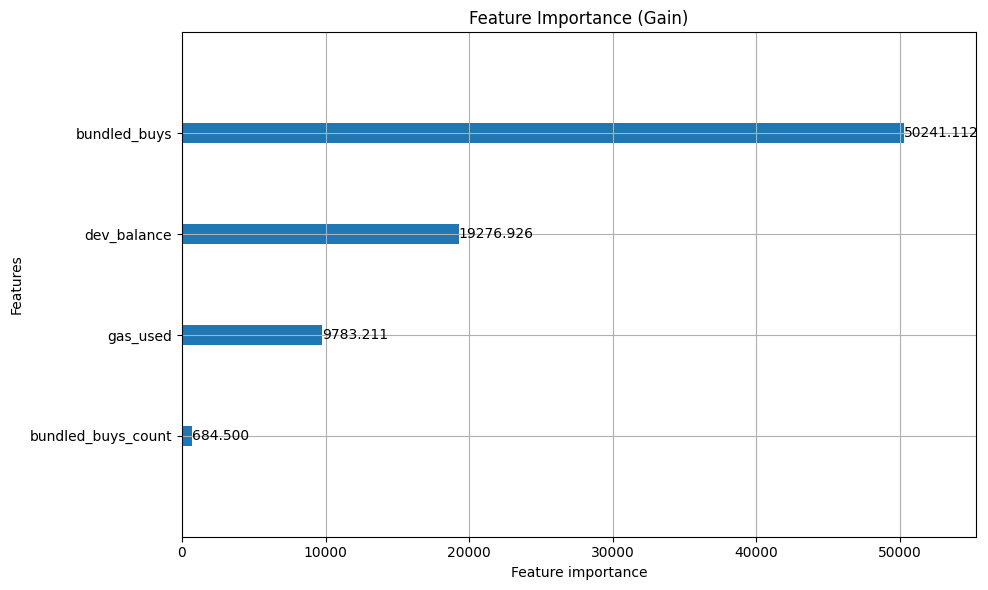

In [ ]:
# Plot feature importance
lgb.plot_importance(model, importance_type='gain', figsize=(10, 6), title='Feature Importance (Gain)')
plt.tight_layout()
plt.show()